# Mini-projeto M2 

## Dataset MNIST (Modified National Institute of Standards and Technology)

O **MNIST** é o dataset "Hello World" da visão computacional, ideal para testar métodos de reconhecimento de padrões com um mínimo esforço de pré-processamento.

### Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

* Importar o dataset MNIST via scikit-learn (fetch_openml('mnist_784')) ou via tensorflow.keras.datasets.mnist.


In [2]:
from sklearn.datasets import fetch_openml

print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")


Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


* Exibir a dimensionalidade das matrizes (X e y) e comprovar a distribuição das classes (balanceamento de dígitos de 0 a 9).

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

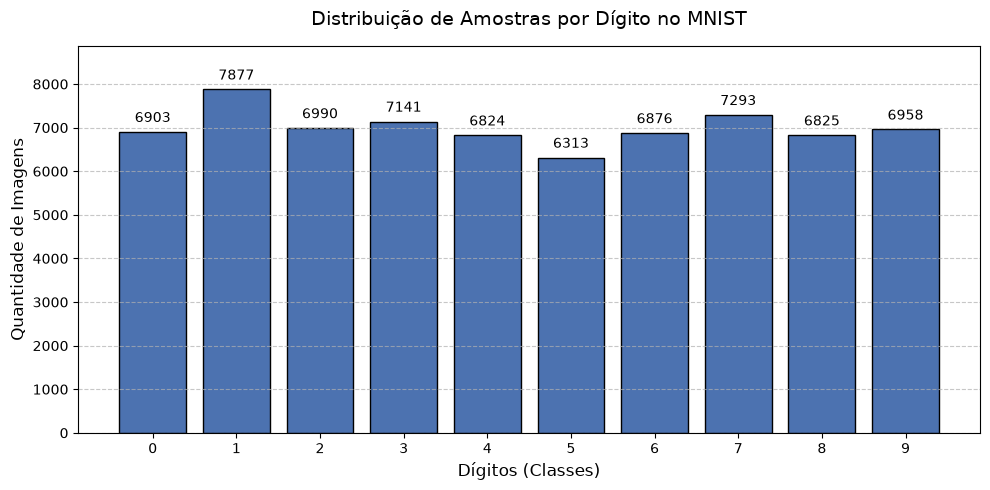

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Descrição completa do dataset
print(mnist.DESCR)
print("Chaves:", mnist.keys())

# Separando as matrizes de features (X) (as imagens) e rótulos/alvo (y) (os rótulos de 0 a 9)
X, y = mnist.data, mnist.target

print("-" * 40)
print("📊 ANÁLISE EXPLORATÓRIA DO MNIST 📊")
print("-" * 40)
print(f"Dimensão de X (Imagens): {X.shape} -> {X.shape[0]} amostras com {X.shape[1]} features cada")
n_pixels = int(np.sqrt(X.shape[1]))
print(f"Formato original de cada feature X: imagem de {n_pixels}x{n_pixels} = {X.shape[1]} pixels")
print(f"Dimensão de y (Rótulos): {y.shape} -> {y.shape[0]} respostas correspondentes")
print(f"Rótulos possíveis: {sorted(set(mnist.target))}")
print("-" * 40)

# -------------------------------------------------------------
# Balanceamento das classes (dígitos de 0 a 9)
classes, contagens = np.unique(y, return_counts=True)
print("\nDistribuição de amostras por dígito:")
for c, count in zip(classes, contagens):
    print(f"Dígito {c}: {count} imagens")

# Vamos fazer um histograma da distribuição
plt.figure(figsize=(10, 5))
barras = plt.bar(classes, contagens, color='#4C72B0', edgecolor='black')

plt.title("Distribuição de Amostras por Dígito no MNIST", fontsize=14, pad=15)
plt.xlabel("Dígitos (Classes)", fontsize=12)
plt.ylabel("Quantidade de Imagens", fontsize=12)
plt.xticks(classes)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 150,
             f'{int(altura)}',
             ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(contagens) + 1000)

plt.tight_layout()
plt.show()


* Gerar uma grade visual  de no mínimo 2 x 5 com matplotlib, exibindo exemplos de imagens de cada dígito junto com seus respectivos rótulos originais.


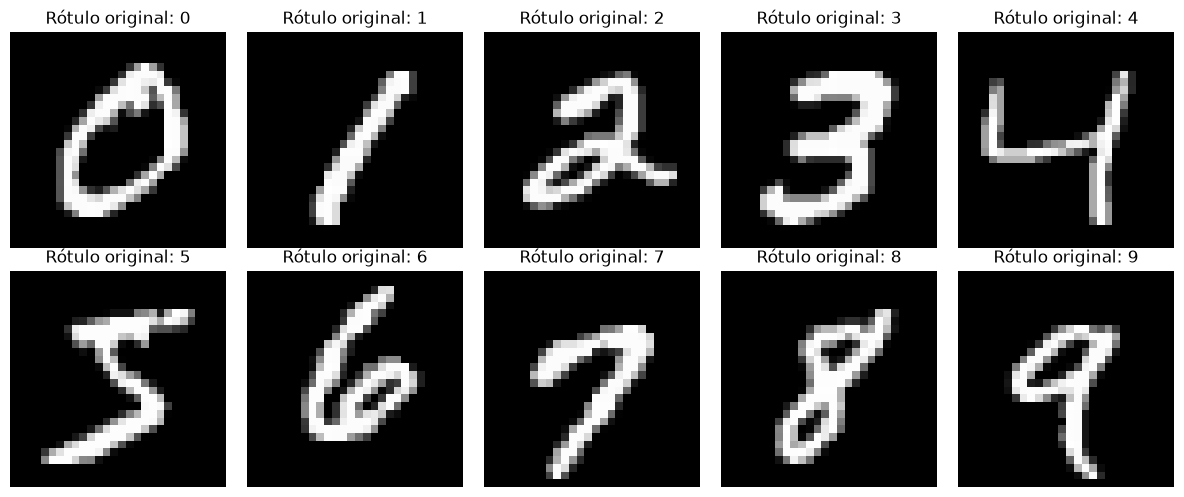

In [4]:
# Extraindo algumas imagens

# Criamos uma grade 2x5 para exibir um exemplo de cada dígito
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    # Garantimos uma imagem de cada número
    idx = np.where(y == str(i))[0][0]

    imagem_28x28 = X[idx].reshape(28, 28)

    axes[i].imshow(imagem_28x28, cmap='gray')
    axes[i].set_title(f"Rótulo original: {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

* Inserir célula de texto interpretando a estrutura dos dados: explicar o significado da escala de intensidade de pixels (0 a 255) e como imagens bidimensionais (28 x 28) são representadas vetorialmente (784 features).

**Estrutura e Origem**

* **Volume Total:** 70.000 imagens de dígitos manuscritos (0 a 9).

* **Autoria:** Criado a partir de bases do NIST americano, misturando amostras escritas por funcionários do censo (base mais limpa) e estudantes do ensino médio (base mais ruidosa).

**Características Técnicas**

* **Formato Original:** Matrizes de $28 \times 28$ pixels. Os dígitos foram normalizados em tamanho e centralizados calculando o "centro de massa" dos pixels.

* **Vetorização:** Para a maioria dos algoritmos, a matriz bidimensional é "achatada" num vetor $\vec{x}$ de **784 dimensões** (features).

* **Intensidade (Pixels):** Escala de cinza de **0** (fundo) a **255** (traço máximo). Os tons de cinza intermediários são resultado da técnica de *anti-aliasing* usada na redução da imagem original.

Então, temos o seguinte problema: cada imagem $i$ é um vetor $\vec{x}^{(i)} = (x_1^{(i)},..., x_{784}^{(i)})$, em que as componentes $x_{j}^{(i)}$ é um pixel com um valor entre $0$ e $255$. Queremos aprender a classificar esses vetores dentros dos rótulos de $0$ a $9$.

**Balanceamento de Classes**

O dataset apresenta uma distribuição muito equilibrada (sem forte viés para nenhum número específico). As amostras variam de forma suave entre o **dígito 5** (classe minoritária, com 6.313 imagens) e o **dígito 1** (classe majoritária, com 7.877 imagens), com a média girando em torno de 7.000 imagens por número.

### Fase 2: Pipeline de Pré-processamento e Divisão dos Dados

* Divisão Estratificada: Dividir a base em Treino, Validação e Teste (ex: 70% treino, 10% validação e 20% teste ou 80% treino/validação e 20% teste), garantindo estratificação por classe (stratify=y).


📊 DIVISÃO ESTRATIFICADA DOS DADOS 📊
--------------------------------------------------
Conjunto de Treino:    49000 amostras (70%)
Conjunto de Validação: 7000  amostras (10%)
Conjunto de Teste:     14000 amostras (20%)
--------------------------------------------------


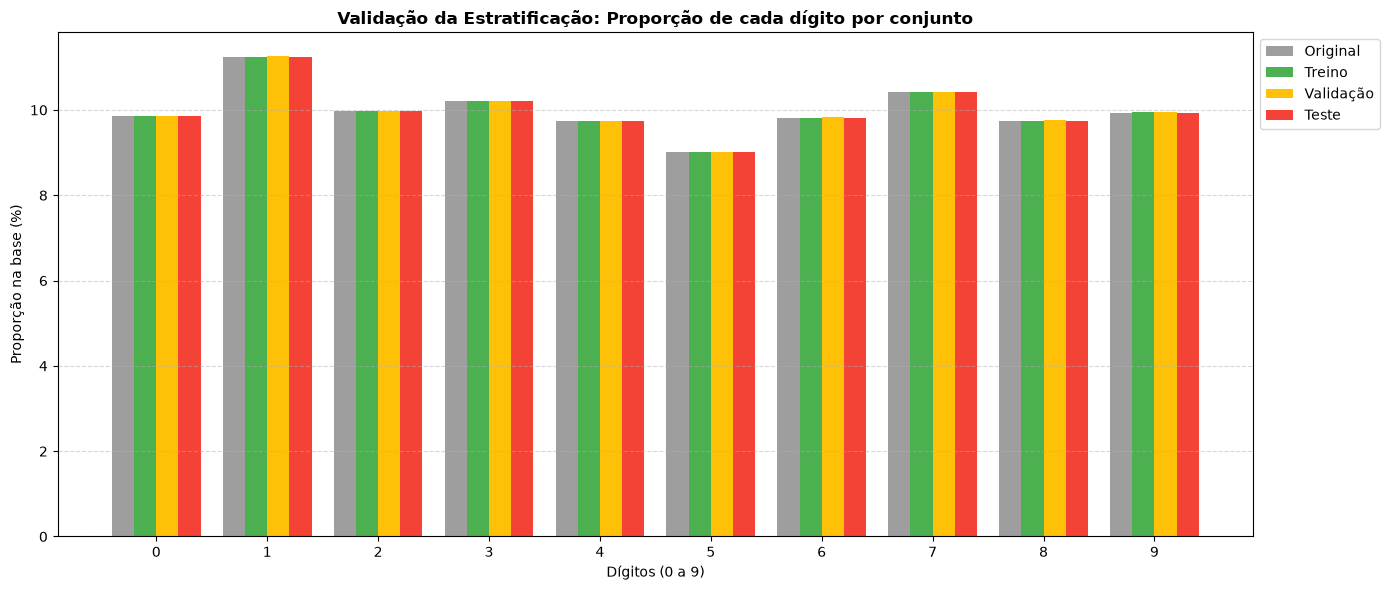

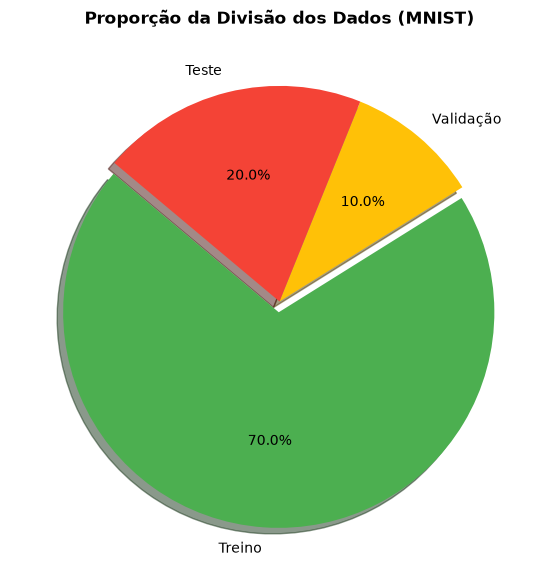

In [5]:
from sklearn.model_selection import train_test_split

# Primeiro vamos separar Teste (20%) e o restante temporário para Treino/Validação (80%)
# Os dados de teste só serão acessados ao final, garantindo que o modelo não teve acesso durante o treino.
# Usamos o stratify para garantir a mesma proporção de classes. Do contrário, por exemplo, poderíamos ter muitos 8 e nenhum 2.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20, # proporção do split 20%
    stratify=y,     # mesma proporção de classes  
    random_state=42 # random padrão para a reprodutibilidade
)

# Separar Validação (10% do total) e Treino (70% do total) a partir do temp
# 12.5% de 80% = 10% do total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    stratify=y_temp,  # Mantemos a estratificação
    random_state=42
)

print("📊 DIVISÃO ESTRATIFICADA DOS DADOS 📊")
print("-" * 50)
print(f"Conjunto de Treino:    {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Conjunto de Validação: {X_val.shape[0]}  amostras ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Conjunto de Teste:     {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")
print("-" * 50)

# ----------------------------------------------------
# Vamos comprovar a eficácia da estratificação (stratify=y)

def check_proportion(y_array):
    _, counts = np.unique(y_array, return_counts=True)
    return (counts / len(y_array)) * 100

# Extraindo as porcentagens para cada conjunto
prop_orig = check_proportion(y)
prop_train = check_proportion(y_train)
prop_val = check_proportion(y_val)
prop_test = check_proportion(y_test)

# Configurações do gráfico
digitos = np.arange(10)
largura = 0.2  # Largura individual de cada barra

plt.figure(figsize=(14, 6))

plt.bar(digitos - largura*1.5, prop_orig, width=largura, label='Original', color='#9E9E9E')
plt.bar(digitos - largura*0.5, prop_train, width=largura, label='Treino', color='#4CAF50')
plt.bar(digitos + largura*0.5, prop_val, width=largura, label='Validação', color='#FFC107')
plt.bar(digitos + largura*1.5, prop_test, width=largura, label='Teste', color='#F44336')

plt.title("Validação da Estratificação: Proporção de cada dígito por conjunto", fontweight='bold')
plt.xlabel("Dígitos (0 a 9)")
plt.ylabel("Proporção na base (%)")
plt.xticks(digitos) # Garante que o eixo X mostre exatamente de 0 a 9
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ----------------------------------------------------
#Vamos fazer um diagrama de pizza

tamanhos = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
labels = ['Treino', 'Validação', 'Teste']
cores = ['#4CAF50', '#FFC107', '#F44336']
destaque = (0.05, 0, 0)  # Afasta levemente a primeira fatia (Treino) para destaque

plt.figure(figsize=(7, 7))
plt.pie(
    tamanhos, 
    labels=labels, 
    colors=cores, 
    autopct='%1.1f%%', 
    explode=destaque,
    startangle=140,
    shadow=True
)

plt.title("Proporção da Divisão dos Dados (MNIST)", fontweight='bold')
plt.show()

* Normalização / Escalonamento: Aplicar o redimensionamento dos pixels para a escala [0.0, 1.0] (dividindo por 255.0 ou via MinMaxScaler/StandardScaler).
  
* Justificar textualmente a importância da normalização para a convergência de modelos lineares e distâncias métricas.

In [6]:
X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

print("📊 VERIFICAÇÃO DO ESCALONAMENTO 📊")
print("-" * 50)
print(f"Treino original:    min {np.min(X_train):.1f} | max {np.max(X_train):.1f}")
print(f"Treino normalizado: min {np.min(X_train_norm):.1f} | max {np.max(X_train_norm):.1f}")
print(f"Teste original:     min {np.min(X_test):.1f} | max {np.max(X_test):.1f}")
print(f"Teste normalizado:  min {np.min(X_test_norm):.1f} | max {np.max(X_test_norm):.1f}")
print("-" * 50)

📊 VERIFICAÇÃO DO ESCALONAMENTO 📊
--------------------------------------------------
Treino original:    min 0.0 | max 255.0
Treino normalizado: min 0.0 | max 1.0
Teste original:     min 0.0 | max 255.0
Teste normalizado:  min 0.0 | max 1.0
--------------------------------------------------


**A Importância Matemática da Normalização [0, 1]**

* **Convergência em Otimizações por Gradiente:** Algoritmos que otimizam pesos minimizando uma função de custo (como regressões logísticas ou redes neurais) dependem da geometria do espaço paramétrico. Quando as *features* possuem escalas muito amplas (0 a 255), as curvas de nível da função de perda tornam-se distorcidas e elípticas, forçando a descida do gradiente a oscilar em "zigue-zague" e atrasando a convergência. Ao redimensionar para [0, 1], a topologia do erro torna-se mais esférica, permitindo que as atualizações dos tensores apontem mais diretamente para o mínimo.
 
* **Estabilidade em Algoritmos Métricos:** Modelos que dependem de similaridade espacial (como KNN ou SVM) calculam rotineiramente a Distância Euclidiana ou de Manhattan. Sem o escalonamento, pixels com valores absolutos naturalmente mais altos dominariam o cálculo da distância hiperespacial de forma desproporcional. A normalização garante que cada dimensão do vetor (pixel) exerça peso equitativo na métrica.

### Fase 3: Implementação e Treinamento dos 3 Modelos

---

#### SVM (Support Vector Machine)

O Support Vector Machine (SVM) é um dos algoritmos de Machine Learning mais robustos e populares para Classificação e Regressão. Ele é um modelo de aprendizado supervisionado, o que significa que opera em um conjunto de dados com rótulos ou alvos conhecidos (com a variável target $y$).

Sua principal função é encontrar a fronteira de decisão ideal (o hiperplano) que separa as diferentes classes de dados com a maior margem de segurança possível, de acordo com as características apresentadas.

##### Nota Histórica

Embora hoje o Deep Learning roube a cena, o SVM tem raízes que remontam à teoria estatística soviética da década de 1960, originando-se de forma independente dos modelos de redes neurais tradicionais. O algoritmo linear base foi inicialmente proposto por Vladimir Vapnik e Alexey Chervonenkis em 1963, no Instituto de Ciências de Controle de Moscou.

Paralelamente, os estudos evoluíram até que, em 1992, Bernhard Boser, Isabelle Guyon e Vapnik introduziram o famoso "Kernel Trick" (Truque do Kernel). A versão padrão iterativa e robusta que usamos hoje (com margens suaves ou *Soft Margins* para lidar com classificações erradas) foi publicada por Corinna Cortes e Vapnik em 1995. É um exemplo clássico de como a matemática elegante e a física estatística sobrevivem ao teste do tempo, moldando a inteligência artificial moderna.

##### Vantagens e Desvantagens

Como qualquer algoritmo de Machine Learning, o SVM não é uma "bala de prata". Entender onde ele brilha e onde ele falha é fundamental para o trabalho de um Cientista de Dados.

**Vantagens:**

* **Eficácia em Alta Dimensionalidade:** É excepcionalmente poderoso em espaços onde o número de dimensões (features) excede o número de amostras.
* **Eficiência de Memória:** Após o treinamento, o modelo constrói a fronteira usando apenas os pontos críticos mais próximos da divisão (os Vetores de Suporte), descartando o restante dos dados.
* **Versatilidade Geométrica (Kernel Trick):** Através de funções matemáticas, o algoritmo consegue traçar fronteiras curvas e complexas de forma implícita, superando o viés de separação puramente linear sem explodir o custo computacional com transformações manuais.
* **Robusto Contra Overfitting:** A natureza do algoritmo em tentar maximizar a distância da margem atua como uma regularização natural, penalizando fronteiras de decisão que ficam complexas demais.

**Desvantagens:**

* **O Problema do Custo Computacional:** Tem complexidade de tempo que cresce de forma quadrática a cúbica (de $\mathcal{O}(n^2)$ a $\mathcal{O}(n^3)$), o que significa que é extremamente lento e não escala bem para conjuntos de dados massivos.
* **Sensibilidade a Ruídos:** Se as classes estiverem muito sobrepostas no espaço ou houver muitos extremos (*outliers*), a otimização da margem pode falhar, exigindo ajustes exaustivos do hiperparâmetro de penalização ($C$).
* **Falta de Transparência Probabilística:** Ao contrário da Regressão Logística, o SVM padrão não retorna nativamente a probabilidade de uma predição estar correta (exigindo cálculos extras pesados, como o escalonamento de Platt).
* **"Caixa Preta" Não Linear:** Quando utilizado com Kernels muito complexos, a lógica exata de uma decisão torna-se opaca, sendo difícil de explicar para partes interessadas (*stakeholders*) não técnicas.

##### Definição Matemática do Problema

Tratamos cada observação como um objeto numérico num espaço multidimensional.

* **Características ($\vec{x}$):** Suponha que tenhamos $N$ características $x_1, \dots, x_N$. No caso de imagens, cada $x_j$ representa a intensidade de cinzento de um pixel específico.
* **Alvo (Target $y^{(i)}$):** É a classificação desejada (ex: o dígito "5" ou a identidade de um rosto).
* **Vetor de Medida ($\vec{x}^{(i)}$):** Após $D$ observações (amostras de treino), seja $\vec{x}^{(i)}$ o vetor da $i$-ésima observação dessas características, ou seja:

$$\vec{x}^{(i)} = (x_{1}^{(i)}, \dots, x_{N}^{(i)})$$

* **Evento:** O conjunto $(\vec{x}^{(i)}, y^{(i)})$ chamamos de **i-ésimo evento**.

---

##### O Hiperplano e a Margem (Apenas 2 Categorias)

O objetivo do algoritmo SVM é encontrar um **hiperplano** de separação num espaço de dimensão $N$ que maximize a distância entre as classes. Então, definimos:

$$f(\vec{x}; \vec{w}, b) := \vec{w} \cdot \vec{x} + b.$$

Aqui:
* $\vec{w}$ é o vetor normal ao hiperplano.
* $b$ é o bias (deslocamento, distância entre o hiperplano e a origem).
* Os **Vetores de Suporte** são os vetores $\vec{x}^{(i)}$ que se encontram exatamente na fronteira da margem.

Também:
* $y^{(i)} = 1$ se a observação $i$ pertence à classe $+1$.
* $y^{(i)} = -1$ se a observação $i$ pertence à classe $-1$.

Os pesos e viés $(\vec{w}, b)$ são obtidos minimizando a **Hinge Loss (Perda de Dobradiça)**:

$$J(\vec{w}, b) = \underbrace{\frac{1}{2} ||\vec{w}||^2_{_2}}_{\textrm{regularização}} + C \left[\frac{1}{D}\sum_{i= 1}^{D} \textrm{max}\left(0; \, 1 - f(\vec{x}^{(i)}; \vec{w}, b) y^{(i)} \right)\right].$$

Após minimizada, separamos em duas classes: $f(\vec{x}^{(i)}; \vec{w}, b) > 0$ e $f(\vec{x}^{(i)}; \vec{w}, b) < 0$.

A equação do hiperplano é:

$$\vec{w} \cdot \vec{x} + b = 0.$$

Definimos as margens de segurança como $\vec{w} \cdot \vec{x} + b = y^{(i)}$:

* $\vec{w} \cdot \vec{x} + b = + 1.$
* $\vec{w} \cdot \vec{x} + b = - 1.$

O termo de regularização maximiza a distância máxima entre o hiperplano e as margens de segurança.

---

##### O Hiperplano e a Margem (Mais de 2 Categorias - Estratégia OvR)

Para problemas com $K$ categorias, o objetivo do algoritmo SVM é encontrar um conjunto de $K$ **hiperplanos** de separação. A estratégia mais comum é a **One-vs-Rest (OvR)**, onde cada classe é comparada contra todas as outras.

Definimos uma função de decisão para cada classe $k \in \{1, \dots, K\}$:

$$f_k(\vec{x}; \vec{w}_k, b_k) := \vec{w}_k \cdot \vec{x} + b_k$$

Aqui:
* $\vec{w}_k$ é o vetor normal ao $k$-ésimo hiperplano.
* $b_k$ é o bias (deslocamento) do $k$-ésimo hiperplano.
* Os **Vetores de Suporte** são as observações $\vec{x}^{(i)}$ que definem a margem de separação entre a classe $k$ e as restantes.

Para cada hiperplano $k$, os pesos e viés $(\vec{w}_k, b_k)$ são obtidos minimizando a **Hinge Loss** específica para essa classe:

$$J(\vec{w}_k, b_k) = \frac{1}{2} ||\vec{w}_k||^2_{_2} + C \left[\frac{1}{D}\sum_{i=1}^D \text{max}\left(0; \, 1 - f_k(\vec{x}^{(i)}; \vec{w}_k, b_k) y^{(i)}(k) \right)\right],$$

em que:
* $y^{(i)}(k) = 1$ se a observação $i$ pertence à classe $k$.
* $y^{(i)}(k) = -1$ se a observação $i$ pertence a qualquer outra classe.

**Decisão Final:** Após a minimização de todos os $K$ problemas, a classificação de um novo vetor $\vec{x}$ é dada pela classe que maximiza a função de decisão:

$$\hat{y} = \text{argmax}_{k \in \{1, \dots, K\}} (\vec{w}_k \cdot \vec{x} + b_k)$$

$$\color{red}{QUAL}\, \color{red}{CATEGORIA}\,\, k\,\, \color{red}{PRODUZIU}\, \color{red}{O}\, \color{red}{MAIOR} \quad f_k(\vec{x})\,?$$

As equações dos hiperplanos de separação são:
$$\vec{w}_k \cdot \vec{x} + b_k = 0, \quad \text{para } k = 1, \dots, K.$$

---

#### Aplicação do SVM no MNIST

Para demonstrar a eficácia da estratégia OvR em um cenário de alta dimensionalidade, aplicaremos o SVM no clássico dataset MNIST. Neste caso, nossos vetores são as imagens, cada $x_j$ é um pixel com valores entre $0$ e $1$ (depois da normalização), $N = 748$ e $D=70000$.

**Justificativa dos Hiperparâmetros:**

* **`kernel='rbf'` (Radial Basis Function):** Para modelar separações não lineares, projetamos os dados originais em um espaço de características de dimensão superior. O hiperplano passa a operar sobre um novo vetor projetado, $\phi(\vec{x})$. A função de decisão teórica seria:

$$f(\vec{x}) = \vec{w} \cdot \phi(\vec{x}) + b$$

No caso específico do kernel RBF (Radial Basis Function), a transformação $\phi(\vec{x})$ mapeia os dados para um espaço de dimensão infinita (devido à expansão em série de Taylor da função exponencial). Como é impossível calcular $\vec{w}$ ou o vetor $\phi(\vec{x})$ explicitamente em infinitas dimensões, aplicamos o **Kernel Trick**. 

A teoria matemática (Teorema de Mercer) prova que não precisamos conhecer $\phi(\vec{x})$. Basta sabermos calcular o produto escalar entre dois vetores nesse novo espaço usando uma função de Kernel $K$ no espaço original:

$$K(\vec{x}^{(i)}, \vec{x}^{(j)}) = \phi(\vec{x}^{(i)}) \cdot \phi(\vec{x}^{(j)}) = \exp\left(-\gamma ||\vec{x}^{(i)} - \vec{x}^{(j)}||^2_{_2}\right)$$

O espaço de características do MNIST (784 dimensões) possui relações espaciais complexas e não lineares entre os pixels. O RBF mapeia esses vetores implicitamente para um espaço de dimensão infinita, permitindo encontrar hiperplanos de separação que seriam impossíveis com um kernel puramente linear.

* **`C=10` (Parâmetro de Regularização):** Controla o compromisso entre maximizar a margem e minimizar os erros de classificação no treino. Um valor maior (10) penaliza rigorosamente as violações da margem (*harder margin*), forçando o modelo a capturar melhor as nuances estruturais dos dígitos, reduzindo o viés.


---------------------------

In [ ]:
#TODO: Melhorar texto

Os hiperparâmetros que vamos variar são:  C (controle de regularização) e kernel (linear, RBF, etc.)

Justificativa: variamos C pois este regula a margem de separação (o quanto estamos penalizando o erro na classificação dos pontos); enquanto o kernel define a forma da fronteira de decisão (pode ser uma linha reta, um círculo, ...).

Para C usaremos os seguintes valores:
- Baixo (0.01–0.1): margem larga, mais tolerância a erros → pode subajustar.
- Médio (1–10): equilíbrio entre generalização e ajuste.
- Alto (100–1000): margem estreita, menos tolerância → risco de overfitting.

Para o kernel usaremos:
- RBF (Radial Basis Function): padrão, captura fronteiras não lineares; exige ajuste de gamma.
- Linear: rápido, bom para dados com muitas features e separação linear.


In [7]:
from sklearn.svm import SVC
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [7]:
X_train_norm.size

38416000

In [8]:
y_train.size

49000

In [10]:
28*28*49000

38416000

In [8]:
# Vamos fazer com sample primeiro
# TODO: usar base completa depois

# reduz o conjunto de treino para 30%
X_train_norm_sample, _, y_train_sample, _ = train_test_split(
    X_train_norm, y_train,
    train_size=0.1,
    stratify=y_train,
    random_state=42
)




In [9]:

resultados = []
    
for c in np.logspace(-2, 2, num=5, base=10):
    for kernel in ['rbf', 'linear']:
        print(f'C = {c}')
        print(f'kernel = {kernel}')

        modelo_svm = SVC(kernel=kernel, C=c, gamma='scale', decision_function_shape='ovr')
        modelo_svm.fit(X_train_norm_sample, y_train_sample)

               
        # Faz previsões
        y_pred = modelo_svm.predict(X_test_norm)
        
        # Calcula métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro')
        rec = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')
        
        resultados.append({
            "C": c,
            "Kernel": kernel,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })




C = 0.01
kernel = rbf


KeyboardInterrupt: 

In [14]:
# Exibir resultados em formato de tabela
import pandas as pd
df_resultados = pd.DataFrame(resultados)
print(df_resultados)

        C  Kernel  Accuracy  Precision    Recall        F1
0    0.01     rbf  0.506071   0.604594  0.490702  0.420901
1    0.01  linear  0.916000   0.915273  0.914866  0.914818
2    0.10     rbf  0.909500   0.908834  0.908521  0.908507
3    0.10  linear  0.919000   0.918341  0.917763  0.917708
4    1.00     rbf  0.947714   0.947216  0.947225  0.947141
5    1.00  linear  0.902714   0.901935  0.901058  0.900832
6   10.00     rbf  0.955429   0.955008  0.954953  0.954924
7   10.00  linear  0.901786   0.901010  0.900136  0.899894
8  100.00     rbf  0.955286   0.954864  0.954812  0.954782
9  100.00  linear  0.901786   0.901010  0.900136  0.899894


---

#### Random Forest 

🔹 Hiperparâmetros que serão testados
- **`n_estimators`** (número de árvores)
  - Teste valores como `[50, 100, 200, 500]`.
  - Mais árvores reduzem variância, mas aumentam tempo de treino.

- **`max_depth`** (profundidade máxima das árvores)
  - Teste `[None, 5, 10, 20]`.
  - `None` deixa crescer até o fim → risco de overfitting.
  - Valores menores forçam generalização.



In [18]:
from sklearn.ensemble import RandomForestClassifier

In [24]:

resultados_rf = []
    
for n_estimator in 50 * np.logspace(0, 3, num=4, base=2):
    for max_depth in 5 * np.logspace(0, 2, num=3, base=2):
        print(f'n_estimator = {n_estimator}')
        print(f'max_depth = {max_depth}')

        modelo_rf = RandomForestClassifier(n_estimators=int(n_estimator), max_depth= int(max_depth), random_state=42, n_jobs=-1 ) 
        modelo_rf.fit(X_train_norm, y_train)

        # Faz previsões
        y_pred = modelo_rf.predict(X_test_norm)
        
        # Calcula métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro')
        rec = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')
        
        resultados_rf.append({
            "n_estimator": n_estimator,
            "max_depth": max_depth,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })




n_estimator = 50.0
max_depth = 5.0
n_estimator = 50.0
max_depth = 10.0
n_estimator = 50.0
max_depth = 20.0
n_estimator = 100.0
max_depth = 5.0
n_estimator = 100.0
max_depth = 10.0
n_estimator = 100.0
max_depth = 20.0
n_estimator = 200.0
max_depth = 5.0
n_estimator = 200.0
max_depth = 10.0
n_estimator = 200.0
max_depth = 20.0
n_estimator = 400.0
max_depth = 5.0
n_estimator = 400.0
max_depth = 10.0
n_estimator = 400.0
max_depth = 20.0


In [25]:
# Exibir resultados em formato de tabela
df_resultados_rf = pd.DataFrame(resultados_rf)
print(df_resultados_rf)

    n_estimator  max_depth  Accuracy  Precision    Recall        F1
0          50.0        5.0  0.854786   0.860060  0.850848  0.851136
1          50.0       10.0  0.941929   0.941964  0.941287  0.941490
2          50.0       20.0  0.963429   0.963233  0.963037  0.963104
3         100.0        5.0  0.858214   0.863829  0.854310  0.854702
4         100.0       10.0  0.944357   0.944387  0.943753  0.943961
5         100.0       20.0  0.964786   0.964619  0.964437  0.964500
6         200.0        5.0  0.860000   0.865488  0.856164  0.856596
7         200.0       10.0  0.944357   0.944326  0.943776  0.943965
8         200.0       20.0  0.965357   0.965299  0.965034  0.965132
9         400.0        5.0  0.864571   0.869504  0.860948  0.861463
10        400.0       10.0  0.945357   0.945425  0.944794  0.945008
11        400.0       20.0  0.965429   0.965339  0.965139  0.965206


### Neural Network

🔹 Hiperparâmetros importantes
- **`hidden_layer_sizes`**  
  - Define o número de neurônios em cada camada oculta.  
  - Exemplo: `(100,)` → uma camada com 100 neurônios.  
  - `(100, 50)` → duas camadas, a primeira com 100 e a segunda com 50 neurônios.  
  - Sugestão: teste `[ (50,), (100,), (100,50), (200,) ]`.

- **`activation`**  
  - Função de ativação das camadas ocultas.  
  - Opções: `"relu"` (mais comum),  `"tanh"`, `"logistic"`.  
  - Sugestão: comece com `"relu"`.


In [10]:
from sklearn.neural_network import MLPClassifier 

In [11]:
resultados_nn = []

# É bom usar potencias de 2 pois são mais próximos do hardware
for layers in [(64, ), (128, ), (16,), (128, 64), (16, 128), (16, 64)]:
    for activation in ["relu", "tanh"]:
        print(f'layers = {layers}')
        print(f'activation = {activation}')

        modelo_nn = MLPClassifier(hidden_layer_sizes=layers, activation= activation ) 
        modelo_nn.fit(X_train_norm_sample, y_train_sample)

        

        # Faz previsões
        y_pred = modelo_nn.predict(X_test_norm)
        
        # Calcula métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro')
        rec = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')
        
        resultados_nn.append({
            "hidden_layer_sizes": layers,
            "activation": activation,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })


layers = (64,)
activation = relu
layers = (64,)
activation = tanh
layers = (128,)
activation = relu
layers = (128,)
activation = tanh
layers = (16,)
activation = relu


c:\Users\chery\Documents\SCTEC\mini-projeto2\sctec-mini-projeto2\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


layers = (16,)
activation = tanh


c:\Users\chery\Documents\SCTEC\mini-projeto2\sctec-mini-projeto2\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


layers = (128, 64)
activation = relu
layers = (128, 64)
activation = tanh
layers = (16, 128)
activation = relu
layers = (16, 128)
activation = tanh
layers = (16, 64)
activation = relu
layers = (16, 64)
activation = tanh


In [13]:
import pandas as pd

In [14]:
# Exibir resultados em formato de tabela
df_resultados_nn = pd.DataFrame(resultados_nn)
print(df_resultados_nn)

   hidden_layer_sizes activation  Accuracy  Precision    Recall        F1
0               (64,)       relu  0.935500   0.934821  0.934632  0.934626
1               (64,)       tanh  0.926286   0.925461  0.925160  0.925183
2              (128,)       relu  0.938429   0.937798  0.937732  0.937665
3              (128,)       tanh  0.931071   0.930299  0.930155  0.930106
4               (16,)       relu  0.901429   0.900023  0.900108  0.899835
5               (16,)       tanh  0.903929   0.902752  0.902535  0.902379
6           (128, 64)       relu  0.939214   0.938821  0.938451  0.938480
7           (128, 64)       tanh  0.933929   0.933193  0.933037  0.933012
8           (16, 128)       relu  0.920429   0.919383  0.919206  0.919179
9           (16, 128)       tanh  0.913643   0.912463  0.912271  0.912175
10           (16, 64)       relu  0.921786   0.920886  0.920523  0.920549
11           (16, 64)       tanh  0.912500   0.911472  0.911201  0.911200


In [1]:
print('Hello')

Hello
